# WritingRing preprocessing / spike-encoding controller

This notebook is a control and diagnostics surface for the repository's current complete-recording pipeline:

`raw ring_0 -> preprocessing / gravity removal -> spike encoding -> post-encode transform`

Design rules used here:

- `action_id` is the immediate action-directory identifier under each user. Its semantic meaning is undocumented; it is not an Action0 class or a timestamp-marker label.
- Timestamp-marker text comes only from the recording's canonical `*_timestamp.txt` sidecar and is audited separately from `action_id`.
- Action0 discovered segment classes, when produced by the separate segmentation pipeline, and Board contact fields are distinct downstream data; this controller does not infer either from `action_id`.
- Only `*_ring_0.bin` is used as the primary Ring input.
- Preprocessing keeps the repository's 9-channel contract: 3 acceleration channels in `g`, the same 3 channels in `m/s^2`, and 3 gyro channels in `rad/s`.
- Spike encoding uses the repository encoder registry (`available_encoders`, `create_encoder`) rather than reimplementing an encoder in the notebook.
- A complete recording is encoded as one state-reset boundary: `[0, N]`.
- For the current `custom-wavelet` encoder, the canonical configuration produces 15 event channels (3 axes x 5 frequencies).
- The current supported post-encode transform for Custom Wavelet is `AbsRectify` (or no transform).

The notebook has two layers:

1. **Dataset + single-recording diagnostics**: safe, in-memory analysis and plots.
2. **Optional production export**: explicit switches at the end run the repository's canonical artifact exporters / CLI.


In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = (start, *start.parents)
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (candidate / "src" / "writingring").is_dir():
            return candidate
    raise RuntimeError(
        "Could not locate the writingRing repository root. "
        "Start Jupyter inside the repository or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")


Repository root: /home/ted/project/writingring-viz


## 1. Configuration

Edit this cell only for normal experiments. The diagnostics use one selected recording; the optional batch-export cells at the end use the same settings.


In [2]:
# Dataset root: prefer the full repository data/ tree; fall back to the documented sample tree.
DATA_ROOT = REPO_ROOT / "data"
if not DATA_ROOT.exists():
    DATA_ROOT = REPO_ROOT / "data_sample" / "data"

# Optional exact recording used for detailed plots. Leave all three as None to use the first discovered recording.
DETAIL_USER: str | None = None
DETAIL_ACTION: str | None = None
DETAIL_DATASET_ID: int | None = None

# Preprocessing controls. These mirror scripts/preprocess_ring_imu.py defaults/options.
SAMPLING_RATE_HZ = 200.0
GRAVITY_METHOD = "low-pass"  # raw | low-pass | madgwick | xylo-rotate-and-remove-gravity
LOW_PASS_CUTOFF_HZ = 0.2
MADGWICK_BETA = 0.1
MADGWICK_PROVISIONAL = False
PREPROCESS_OUTPUT_DTYPE = "float32"

# Spike encoding controls. The selected name is validated against the repository registry.
ENCODER_NAME = "custom-wavelet"
ENCODER_SETTINGS_PATHS = {
    "custom-wavelet": REPO_ROOT / "configs" / "spike_encoding" / "custom_wavelet.json",
}

# Post-transform controls. Current Custom Wavelet supports None or "AbsRectify".
POST_ENCODE_TRANSFORM: str | None = "AbsRectify"

# Plot controls. Plot decimation changes visualization only, never processing or counts.
PLOT_MAX_POINTS = 6000

# Optional production artifact export controls. They are intentionally off by default.
RUN_BATCH_PREPROCESSING_EXPORT = False
RUN_BATCH_SPIKE_EXPORT = False
OVERWRITE = False

PREPROCESSED_OUTPUT_ROOT = REPO_ROOT / "outputs" / "preprocessedIMU"
SPIKE_OUTPUT_ROOT = REPO_ROOT / "outputs" / "spikeEncoding"

print(f"DATA_ROOT = {DATA_ROOT}")


DATA_ROOT = /home/ted/project/writingring-viz/data


## 2. Dataset inventory before preprocessing

The repository hierarchy is `data/user/action_id/dataset_id_ring_0.bin`. This section reports recording identity as `user`, `action_id`, and `dataset_id`; `action_id` is a nonsemantic action-directory identifier whose meaning is undocumented, not a class or label. Sample counts are derived from file size (`float64`, 7 values per row), so this inventory does not need to load every recording into memory.

The timestamp-marker audit immediately below is separate: it reads only available canonical timestamp sidecars and never falls back to `action_id`.


In [3]:
from writingring.discovery import discover_recordings
from writingring.ring_loader import FLOAT64_SIZE_BYTES, VALUES_PER_SAMPLE

recordings = discover_recordings(DATA_ROOT)
if not recordings:
    raise RuntimeError(f"No primary *_ring_0.bin recordings found under {DATA_ROOT}")

rows: list[dict[str, object]] = []
for recording in recordings:
    file_size = recording.ring_0_path.stat().st_size
    denominator = FLOAT64_SIZE_BYTES * VALUES_PER_SAMPLE
    sample_count = file_size // denominator if file_size % denominator == 0 else np.nan
    rows.append(
        {
            "user": recording.user,
            "action_id": recording.action,
            "dataset_id": recording.dataset_id,
            "raw_sample_count": sample_count,
            "ring_0_path": str(recording.ring_0_path),
        }
    )

inventory = pd.DataFrame(rows).sort_values(["user", "action_id", "dataset_id"]).reset_index(drop=True)

basic_info = pd.Series(
    {
        "users": inventory["user"].nunique(),
        "action_ids": inventory["action_id"].nunique(),
        "recordings": len(inventory),
        "raw_samples": int(inventory["raw_sample_count"].sum()),
    },
    name="value",
)

display(basic_info.to_frame())
display(inventory)


,value
users,21
action_ids,6
recordings,606
raw_samples,9642001


,user,action_id,dataset_id,raw_sample_count,ring_0_path
0,user_0,0,0,10247,/home/ted/project/writingring-viz/data/user_0/...
1,user_0,0,1,11812,/home/ted/project/writingring-viz/data/user_0/...
2,user_0,0,2,10158,/home/ted/project/writingring-viz/data/user_0/...
3,user_0,0,3,11651,/home/ted/project/writingring-viz/data/user_0/...
4,user_0,1,0,11631,/home/ted/project/writingring-viz/data/user_0/...
...,...,...,...,...,...
601,user_9,5,1,15068,/home/ted/project/writingring-viz/data/user_9/...
602,user_9,5,2,14838,/home/ted/project/writingring-viz/data/user_9/...
603,user_9,5,3,17551,/home/ted/project/writingring-viz/data/user_9/...
604,user_9,5,4,13607,/home/ted/project/writingring-viz/data/user_9/...


In [4]:
# Coverage of each nonsemantic action-directory identifier within each user.
per_user_recordings_by_action_id = inventory.pivot_table(
    index="user",
    columns="action_id",
    values="dataset_id",
    aggfunc="count",
    fill_value=0,
)
per_user_samples_by_action_id = inventory.pivot_table(
    index="user",
    columns="action_id",
    values="raw_sample_count",
    aggfunc="sum",
    fill_value=0,
)

# Coverage of action IDs across the whole discovered recording inventory.
global_action_id_distribution = (
    inventory.groupby("action_id", as_index=False)
    .agg(
        recording_count=("dataset_id", "count"),
        raw_sample_count=("raw_sample_count", "sum"),
        user_count=("user", "nunique"),
    )
    .sort_values("action_id")
    .reset_index(drop=True)
)

print("Recording count per user x action_id (directory coverage; not classes)")
display(per_user_recordings_by_action_id)
print("Raw sample count per user x action_id (directory coverage; not classes)")
display(per_user_samples_by_action_id)
print("Whole-dataset action_id coverage (not a label/class distribution)")
display(global_action_id_distribution)


Recording count per user x action_id (directory coverage; not classes)


action_id,0,1,2,3,4,5
user,,,,,,
user_0,4,4,6,6,6,6
user_1,6,6,4,4,4,4
user_10,6,6,4,4,4,4
user_11,4,4,4,4,4,4
user_12,4,4,6,6,6,6
user_13,4,4,6,6,6,6
user_14,4,4,6,6,6,6
user_15,4,4,6,6,6,3
user_16,4,4,6,6,6,6


Raw sample count per user x action_id (directory coverage; not classes)


action_id,0,1,2,3,4,5
user,,,,,,
user_0,43868,44015,144319,131740,117002,111315
user_1,64712,46448,69477,56085,55321,52269
user_10,50860,42046,62840,59485,53920,49808
user_11,78136,58845,88350,72984,88982,81705
user_12,60895,50350,134468,106173,112493,109864
user_13,54551,40245,90264,82421,86060,79031
user_14,57253,41424,109087,86239,94783,89365
user_15,54675,39276,118342,65548,0,0
user_16,47090,38360,97303,83563,100437,98985


Whole-dataset action_id coverage (not a label/class distribution)


,action_id,recording_count,raw_sample_count,user_count
0,0,96,1227454,21
1,1,96,985681,21
2,2,104,2099193,21
3,3,104,1811730,21
4,4,105,1835533,21
5,5,101,1682410,21


## 2.1 Canonical timestamp-marker audit (diagnostic only)

Each discovered recording is audited independently. If `recording.timestamp_path` is missing, it is reported in the missing-sidecar table; `action_id` is never used as a fallback. When a sidecar exists, `load_timestamp_labels()` is the canonical parser. The audit preserves the parser's case-preserved marker text and one-based source line, plus the exact raw source line with only its line terminator removed.

The totals and marker-text distribution below are **diagnostic only**. They are not a segmentation export, an Action0 target/class map, or a Board-contact-label distribution. `is_wrong_start_marker` is true only when the parsed marker text case-folds to `"wrong"`; `wrong` is an invalid segment-start marker, not a class.


In [5]:
from writingring.segmentation import SegmentLabelParseError, load_timestamp_labels


def _remove_line_terminator(line: str) -> str:
    """Return one source line without only its newline terminator."""
    if line.endswith("\r\n"):
        return line[:-2]
    if line.endswith(("\n", "\r")):
        return line[:-1]
    return line


def _raw_sidecar_line(path: Path, source_line_number: int) -> str:
    """Read a parser-reported one-based source line without reparsing it."""
    raw_lines = Path(path).read_text(encoding="utf-8").splitlines(keepends=True)
    if not 1 <= source_line_number <= len(raw_lines):
        raise IndexError(
            f"source line {source_line_number} is not present in timestamp sidecar {path}"
        )
    return _remove_line_terminator(raw_lines[source_line_number - 1])


_TIMESTAMP_AUDIT_COLUMNS = [
    "user",
    "action_id",
    "dataset_id",
    "timestamp_sidecar_path",
    "timestamp_us",
    "source_line_number",
    "timestamp_marker_text",
    "raw_sidecar_line",
    "is_wrong_start_marker",
]
_TIMESTAMP_MISSING_COLUMNS = [
    "user",
    "action_id",
    "dataset_id",
    "timestamp_sidecar_path",
    "reason",
]
_TIMESTAMP_ERROR_COLUMNS = [
    "user",
    "action_id",
    "dataset_id",
    "timestamp_sidecar_path",
    "error_type",
    "error",
]

timestamp_marker_rows: list[dict[str, object]] = []
missing_timestamp_sidecar_rows: list[dict[str, object]] = []
timestamp_sidecar_error_rows: list[dict[str, object]] = []

for discovered_recording in recordings:
    timestamp_path = discovered_recording.timestamp_path
    recording_identity = {
        "user": discovered_recording.user,
        "action_id": discovered_recording.action,
        "dataset_id": discovered_recording.dataset_id,
    }
    if timestamp_path is None:
        missing_timestamp_sidecar_rows.append(
            {
                **recording_identity,
                "timestamp_sidecar_path": None,
                "reason": "recording.timestamp_path is missing",
            }
        )
        continue

    try:
        timestamp_markers = load_timestamp_labels(timestamp_path)
    except SegmentLabelParseError as error:
        timestamp_sidecar_error_rows.append(
            {
                **recording_identity,
                "timestamp_sidecar_path": str(timestamp_path),
                "error_type": type(error).__name__,
                "error": str(error),
            }
        )
        continue

    for timestamp_marker in timestamp_markers:
        marker_text = timestamp_marker.label
        timestamp_marker_rows.append(
            {
                **recording_identity,
                "timestamp_sidecar_path": str(timestamp_path),
                "timestamp_us": timestamp_marker.timestamp_us,
                "source_line_number": timestamp_marker.source_line_number,
                "timestamp_marker_text": marker_text,
                "raw_sidecar_line": _raw_sidecar_line(
                    timestamp_path, timestamp_marker.source_line_number
                ),
                "is_wrong_start_marker": marker_text.casefold() == "wrong",
            }
        )

timestamp_marker_audit = pd.DataFrame(timestamp_marker_rows, columns=_TIMESTAMP_AUDIT_COLUMNS)
missing_timestamp_sidecars = pd.DataFrame(
    missing_timestamp_sidecar_rows,
    columns=_TIMESTAMP_MISSING_COLUMNS,
)
timestamp_sidecar_parse_errors = pd.DataFrame(
    timestamp_sidecar_error_rows,
    columns=_TIMESTAMP_ERROR_COLUMNS,
)

timestamp_marker_totals = pd.Series(
    {
        "recordings_discovered": len(recordings),
        "timestamp_sidecars_present": sum(
            discovered_recording.timestamp_path is not None
            for discovered_recording in recordings
        ),
        "timestamp_sidecars_missing": len(missing_timestamp_sidecars),
        "timestamp_sidecars_with_parse_error": len(timestamp_sidecar_parse_errors),
        "parsed_timestamp_marker_count": len(timestamp_marker_audit),
        "wrong_start_marker_count": int(
            timestamp_marker_audit["is_wrong_start_marker"].sum()
        ),
    },
    name="count",
)

print(
    "Diagnostic only: raw timestamp-marker totals are not a segmentation export, "
    "Action0 target/class map, or Board-contact-label distribution."
)
display(timestamp_marker_totals.to_frame())

print("Missing timestamp sidecars (reported separately; no action_id fallback)")
display(missing_timestamp_sidecars)

print("Timestamp sidecars with SegmentLabelParseError (reported per sidecar)")
display(timestamp_sidecar_parse_errors)

if timestamp_marker_audit.empty:
    timestamp_marker_distribution = pd.DataFrame(
        columns=["timestamp_marker_text", "is_wrong_start_marker", "marker_count"]
    )
else:
    timestamp_marker_distribution = (
        timestamp_marker_audit.groupby(
            ["timestamp_marker_text", "is_wrong_start_marker"],
            as_index=False,
            dropna=False,
        )
        .size()
        .rename(columns={"size": "marker_count"})
        .sort_values(
            ["is_wrong_start_marker", "timestamp_marker_text"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )

print(
    "Timestamp-marker text distribution (diagnostic only; `wrong` is an "
    "invalid segment-start marker, not a class)"
)
display(timestamp_marker_distribution)
display(timestamp_marker_audit)


Diagnostic only: raw timestamp-marker totals are not a segmentation export, Action0 target/class map, or Board-contact-label distribution.


,count
recordings_discovered,606
timestamp_sidecars_present,606
timestamp_sidecars_missing,0
timestamp_sidecars_with_parse_error,0
parsed_timestamp_marker_count,13356
wrong_start_marker_count,257


Missing timestamp sidecars (reported separately; no action_id fallback)


,user,action_id,dataset_id,timestamp_sidecar_path,reason


Timestamp sidecars with SegmentLabelParseError (reported per sidecar)


,user,action_id,dataset_id,timestamp_sidecar_path,error_type,error


Timestamp-marker text distribution (diagnostic only; `wrong` is an invalid segment-start marker, not a class)


,timestamp_marker_text,is_wrong_start_marker,marker_count
0,wrong,True,257
1,A,False,193
2,ABANDONED,False,2
3,ABOUT,False,4
4,ACCIDENT,False,2
...,...,...,...
1160,yes,False,2
1161,you,False,45
1162,your,False,20
1163,z,False,96


,user,action_id,dataset_id,timestamp_sidecar_path,timestamp_us,source_line_number,timestamp_marker_text,raw_sidecar_line,is_wrong_start_marker
0,user_0,0,0,/home/ted/project/writingring-viz/data/user_0/...,1.720476e+15,1,s,1720476256688618 s,False
1,user_0,0,0,/home/ted/project/writingring-viz/data/user_0/...,1.720476e+15,2,l,1720476259240937 l,False
2,user_0,0,0,/home/ted/project/writingring-viz/data/user_0/...,1.720476e+15,3,t,1720476260694202 t,False
3,user_0,0,0,/home/ted/project/writingring-viz/data/user_0/...,1.720476e+15,4,f,1720476262687873 f,False
4,user_0,0,0,/home/ted/project/writingring-viz/data/user_0/...,1.720476e+15,5,j,1720476264384004 j,False
...,...,...,...,...,...,...,...,...,...
13351,user_9,5,5,/home/ted/project/writingring-viz/data/user_9/...,1.720745e+15,16,A,1720744611481567 A,False
13352,user_9,5,5,/home/ted/project/writingring-viz/data/user_9/...,1.720745e+15,17,FEW,1720744612764870 FEW,False
13353,user_9,5,5,/home/ted/project/writingring-viz/data/user_9/...,1.720745e+15,18,MORE,1720744616001665 MORE,False
13354,user_9,5,5,/home/ted/project/writingring-viz/data/user_9/...,1.720745e+15,19,PHRASES,1720744620242107 PHRASES,False


## 3. Select one recording for detailed diagnostics

If no exact selector is configured above, the first discovered recording is used. The same raw recording is used for the gravity-removal, spike-encoding, and post-transform plots so comparisons stay row-aligned. The selected `action_id` remains a recording identifier only; it is not treated as a label or class.


In [6]:
from writingring.ring_loader import RELATIVE_TIME_COLUMN, load_ring


def select_recording():
    selectors = (DETAIL_USER, DETAIL_ACTION, DETAIL_DATASET_ID)
    if all(value is None for value in selectors):
        return recordings[0]
    if any(value is None for value in selectors):
        raise ValueError("DETAIL_USER, DETAIL_ACTION, and DETAIL_DATASET_ID must be set together")
    for recording in recordings:
        if (
            recording.user == DETAIL_USER
            and recording.action == DETAIL_ACTION
            and recording.dataset_id == DETAIL_DATASET_ID
        ):
            return recording
    raise ValueError(
        f"Recording not found: {DETAIL_USER}/{DETAIL_ACTION}/{DETAIL_DATASET_ID}"
    )


recording = select_recording()
ring = load_ring(recording)

if RELATIVE_TIME_COLUMN in ring.dataframe.columns:
    time_s = ring.dataframe[RELATIVE_TIME_COLUMN].to_numpy(dtype=np.float64, copy=True)
else:
    time_s = np.arange(len(ring.dataframe), dtype=np.float64) / SAMPLING_RATE_HZ

print(f"Selected recording: {recording.user}/{recording.action} (action_id)/{recording.dataset_id}")
print(f"Samples: {len(ring.dataframe):,}")
print(f"Raw shape: {ring.raw_shape}")
print(f"Inferred sampling rate: {ring.validation.inferred_sampling_rate_hz}")
if ring.warnings:
    print("Warnings:")
    for warning in ring.warnings:
        print(f"  - {warning}")


Selected recording: user_0/0 (action_id)/0
Samples: 10,247
Raw shape: (10247, 7)
Inferred sampling rate: 200.88783955088647
Warnings:
  - 7148 duplicate timestamp step(s) observed


## 4. Preprocessing / gravity removal

This calls the repository's `preprocess_ring_imu()` directly and therefore preserves the current 9-channel contract. The figure compares measured acceleration before preprocessing with the selected gravity-removal result after preprocessing.


In [7]:
from writingring.gravity import GravityRemovalConfig
from writingring.imu_preprocessing import PREPROCESSED_IMU_COLUMNS, preprocess_ring_imu

if GRAVITY_METHOD not in {"raw", "low-pass", "madgwick", "xylo-rotate-and-remove-gravity"}:
    raise ValueError(f"Unsupported GRAVITY_METHOD: {GRAVITY_METHOD}")

preprocessing_config = GravityRemovalConfig(
    sampling_rate_hz=SAMPLING_RATE_HZ,
    gravity_removal_method=GRAVITY_METHOD,
    low_pass_cutoff_hz=LOW_PASS_CUTOFF_HZ,
    madgwick_beta=MADGWICK_BETA,
    strict_calibration=(GRAVITY_METHOD == "madgwick" and not MADGWICK_PROVISIONAL),
)

preprocessed = preprocess_ring_imu(ring, config=preprocessing_config)

preprocessing_summary = pd.Series(
    {
        "method": preprocessed.method,
        "acceleration_semantics": preprocessed.acceleration_semantics,
        "sample_count": len(preprocessed.imu),
        "channel_count": preprocessed.imu.shape[1],
        "sampling_rate_hz": SAMPLING_RATE_HZ,
        "gravity_removed": GRAVITY_METHOD != "raw",
        "output_shape": preprocessed.imu.shape,
    },
    name="value",
)

display(preprocessing_summary.to_frame())
print("Channel order:")
for index, name in enumerate(PREPROCESSED_IMU_COLUMNS):
    print(f"  {index:2d}: {name}")


,value
method,low-pass
acceleration_semantics,gravity_removed_linear_acceleration
sample_count,10247
channel_count,9
sampling_rate_hz,200.0
gravity_removed,True
output_shape,"(10247, 9)"


Channel order:
   0: acceleration_x_g
   1: acceleration_y_g
   2: acceleration_z_g
   3: acceleration_x
   4: acceleration_y
   5: acceleration_z
   6: gyro_x
   7: gyro_y
   8: gyro_z


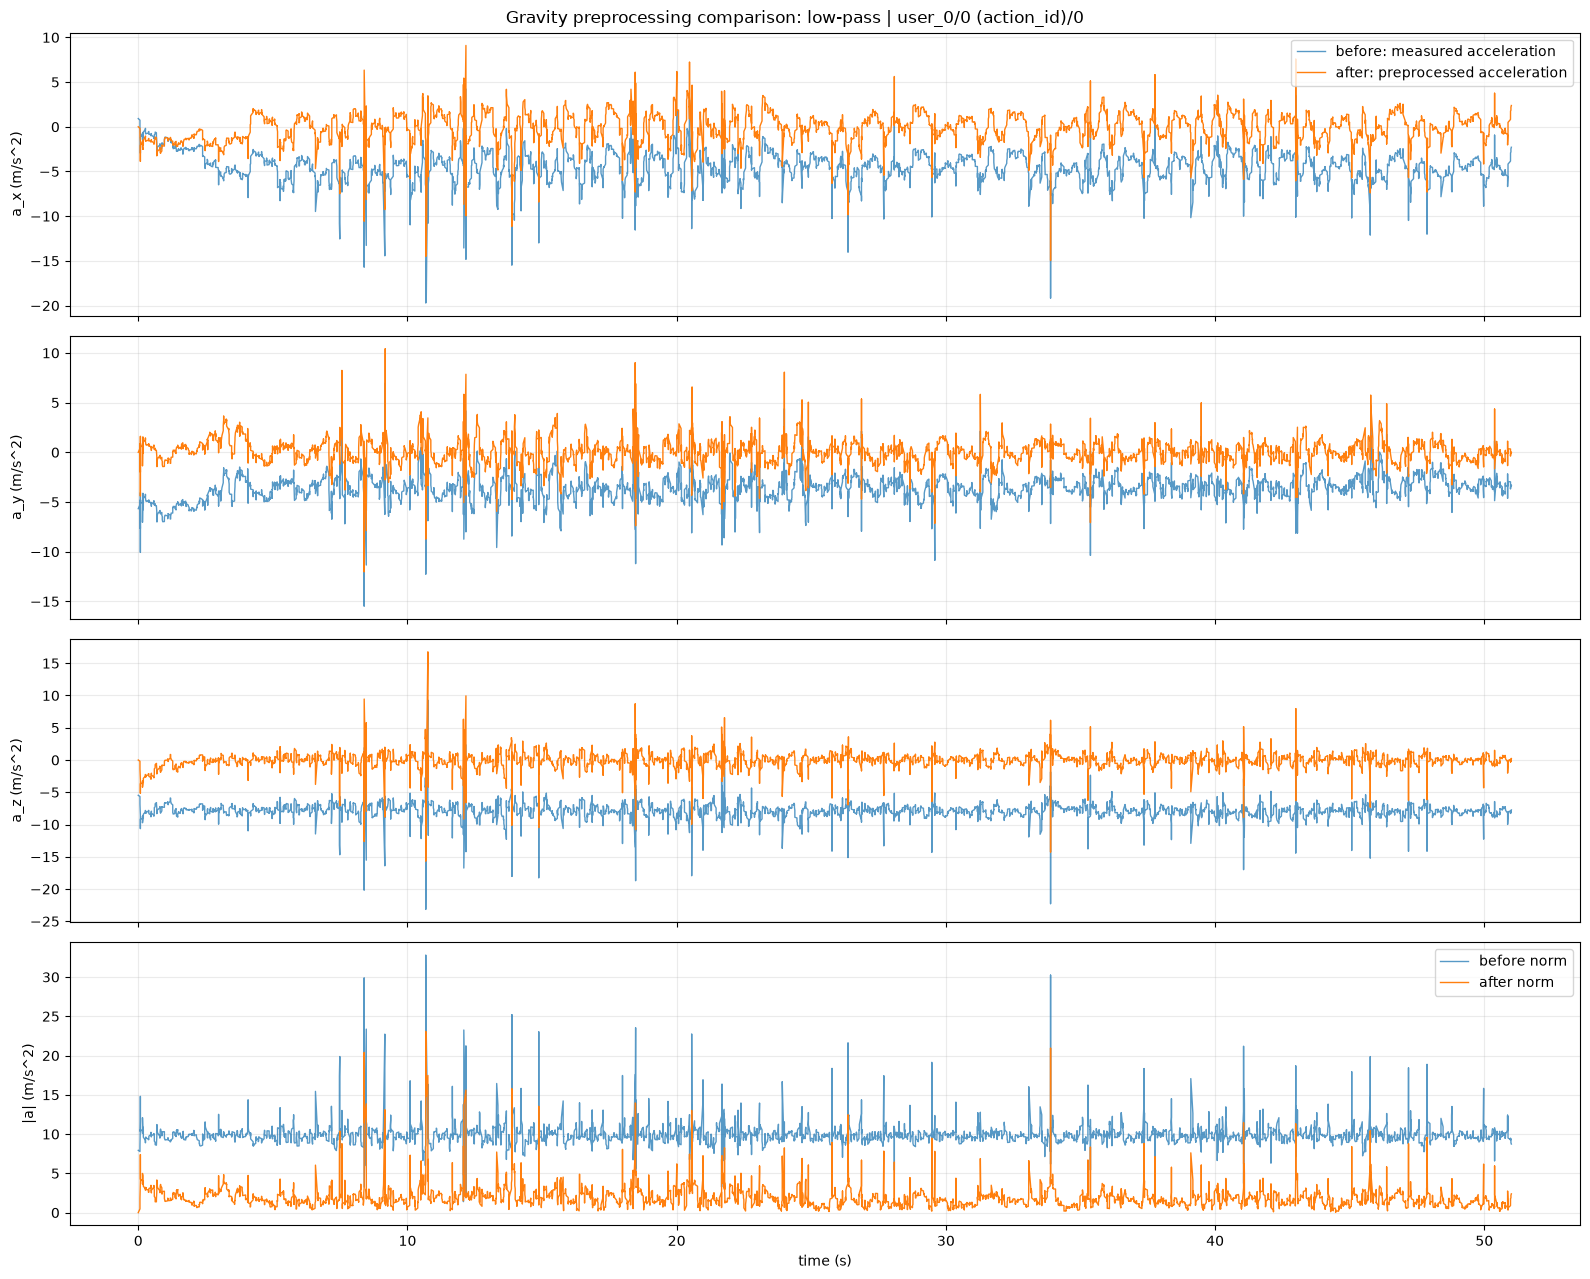

In [8]:
def decimated_indices(length: int, max_points: int = PLOT_MAX_POINTS) -> np.ndarray:
    if length <= max_points:
        return np.arange(length)
    return np.unique(np.linspace(0, length - 1, max_points, dtype=int))


raw_acc_m_s2 = ring.dataframe[["acc_x", "acc_y", "acc_z"]].to_numpy(dtype=np.float64, copy=True)
processed_acc_m_s2 = preprocessed.acceleration_m_s2
plot_idx = decimated_indices(len(time_s))
axis_names = ("x", "y", "z")

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
for axis_index, axis_name in enumerate(axis_names):
    ax = axes[axis_index]
    ax.plot(time_s[plot_idx], raw_acc_m_s2[plot_idx, axis_index], label="before: measured acceleration", linewidth=1.0, alpha=0.75)
    ax.plot(time_s[plot_idx], processed_acc_m_s2[plot_idx, axis_index], label="after: preprocessed acceleration", linewidth=1.0)
    ax.set_ylabel(f"a_{axis_name} (m/s^2)")
    ax.grid(alpha=0.25)
    if axis_index == 0:
        ax.legend(loc="upper right")

raw_norm = np.linalg.norm(raw_acc_m_s2, axis=1)
processed_norm = np.linalg.norm(processed_acc_m_s2, axis=1)
axes[3].plot(time_s[plot_idx], raw_norm[plot_idx], label="before norm", linewidth=1.0, alpha=0.75)
axes[3].plot(time_s[plot_idx], processed_norm[plot_idx], label="after norm", linewidth=1.0)
axes[3].set_ylabel("|a| (m/s^2)")
axes[3].set_xlabel("time (s)")
axes[3].grid(alpha=0.25)
axes[3].legend(loc="upper right")

fig.suptitle(f"Gravity preprocessing comparison: {GRAVITY_METHOD} | {recording.user}/{recording.action} (action_id)/{recording.dataset_id}")
fig.tight_layout()
plt.show()


## 5. Spike encoding before post-transform

The encoder is selected by `ENCODER_NAME` and created through the repository registry. For the current Custom Wavelet path, this cell explicitly disables the post-encode transform so the output is the signed occurrence-aligned event representation.

`spike_count` below means **number of nonzero event rows in that channel**, because Custom Wavelet emits sparse signed amplitudes rather than a binary 0/1 train.


In [9]:
from writingring.spike_encoding import (
    available_encoders,
    create_encoder,
    load_encoder_settings,
    run_spike_encoder,
    single_array_offsets,
)

registered_encoders = available_encoders()
print("Registered spike encoders:", registered_encoders)
if ENCODER_NAME not in registered_encoders:
    raise ValueError(
        f"ENCODER_NAME={ENCODER_NAME!r} is not registered. Available: {registered_encoders}"
    )
if ENCODER_NAME not in ENCODER_SETTINGS_PATHS:
    raise ValueError(
        f"Add a settings path for {ENCODER_NAME!r} to ENCODER_SETTINGS_PATHS before running it."
    )

encoder_settings_path = ENCODER_SETTINGS_PATHS[ENCODER_NAME]
base_encoder_settings = load_encoder_settings(encoder_settings_path)

# Keep the preprocessing and encoder sampling-rate contracts aligned.
if "sampling_rate_hz" in base_encoder_settings:
    configured_rate = float(base_encoder_settings["sampling_rate_hz"])
    if configured_rate != float(SAMPLING_RATE_HZ):
        raise ValueError(
            f"Encoder sampling rate ({configured_rate}) does not match preprocessing ({SAMPLING_RATE_HZ})."
        )

pre_transform_settings = dict(base_encoder_settings)
if ENCODER_NAME == "custom-wavelet":
    pre_transform_settings["post_encode_transform"] = None

encoder_before_post = create_encoder(ENCODER_NAME, settings=pre_transform_settings)
recording_offsets = single_array_offsets(sample_count=len(preprocessed.acceleration_g))
encoding_before_post = run_spike_encoder(
    encoder_before_post,
    acceleration_g=preprocessed.acceleration_g,
    sequence_offsets=recording_offsets,
    sequence_boundary_semantics="recording",
)

spikes_before_post = np.asarray(encoding_before_post.values)
spike_channel_names = encoding_before_post.channel_names

print(f"Encoder: {encoding_before_post.encoder_name}")
print(f"Representation: {encoding_before_post.representation}")
print(f"Output shape: {spikes_before_post.shape}")
if ENCODER_NAME == "custom-wavelet" and spikes_before_post.shape[1] != 15:
    raise AssertionError("Current Custom Wavelet contract must produce exactly 15 event channels")


Registered spike encoders: ('custom-wavelet',)
Encoder: custom-wavelet
Representation: signed_sparse_wavelet_extrema
Output shape: (10247, 15)


,channel_index,channel,spike_count,positive_count,negative_count,density,max_abs_amplitude
0,0,event_x_0p5_hz,63,30,33,0.006148,1.960027
1,1,event_x_1_hz,125,60,65,0.012199,1.865838
2,2,event_x_2_hz,181,98,83,0.017664,2.429435
3,3,event_x_4_hz,247,129,118,0.024105,2.229251
4,4,event_x_8_hz,234,118,116,0.022836,1.787564
5,5,event_y_0p5_hz,72,38,34,0.007026,1.532376
6,6,event_y_1_hz,130,66,64,0.012687,1.201565
7,7,event_y_2_hz,203,100,103,0.019811,1.628938
8,8,event_y_4_hz,274,137,137,0.026740,1.233652
9,9,event_y_8_hz,256,129,127,0.024983,0.843066


Total nonzero events: 2,823


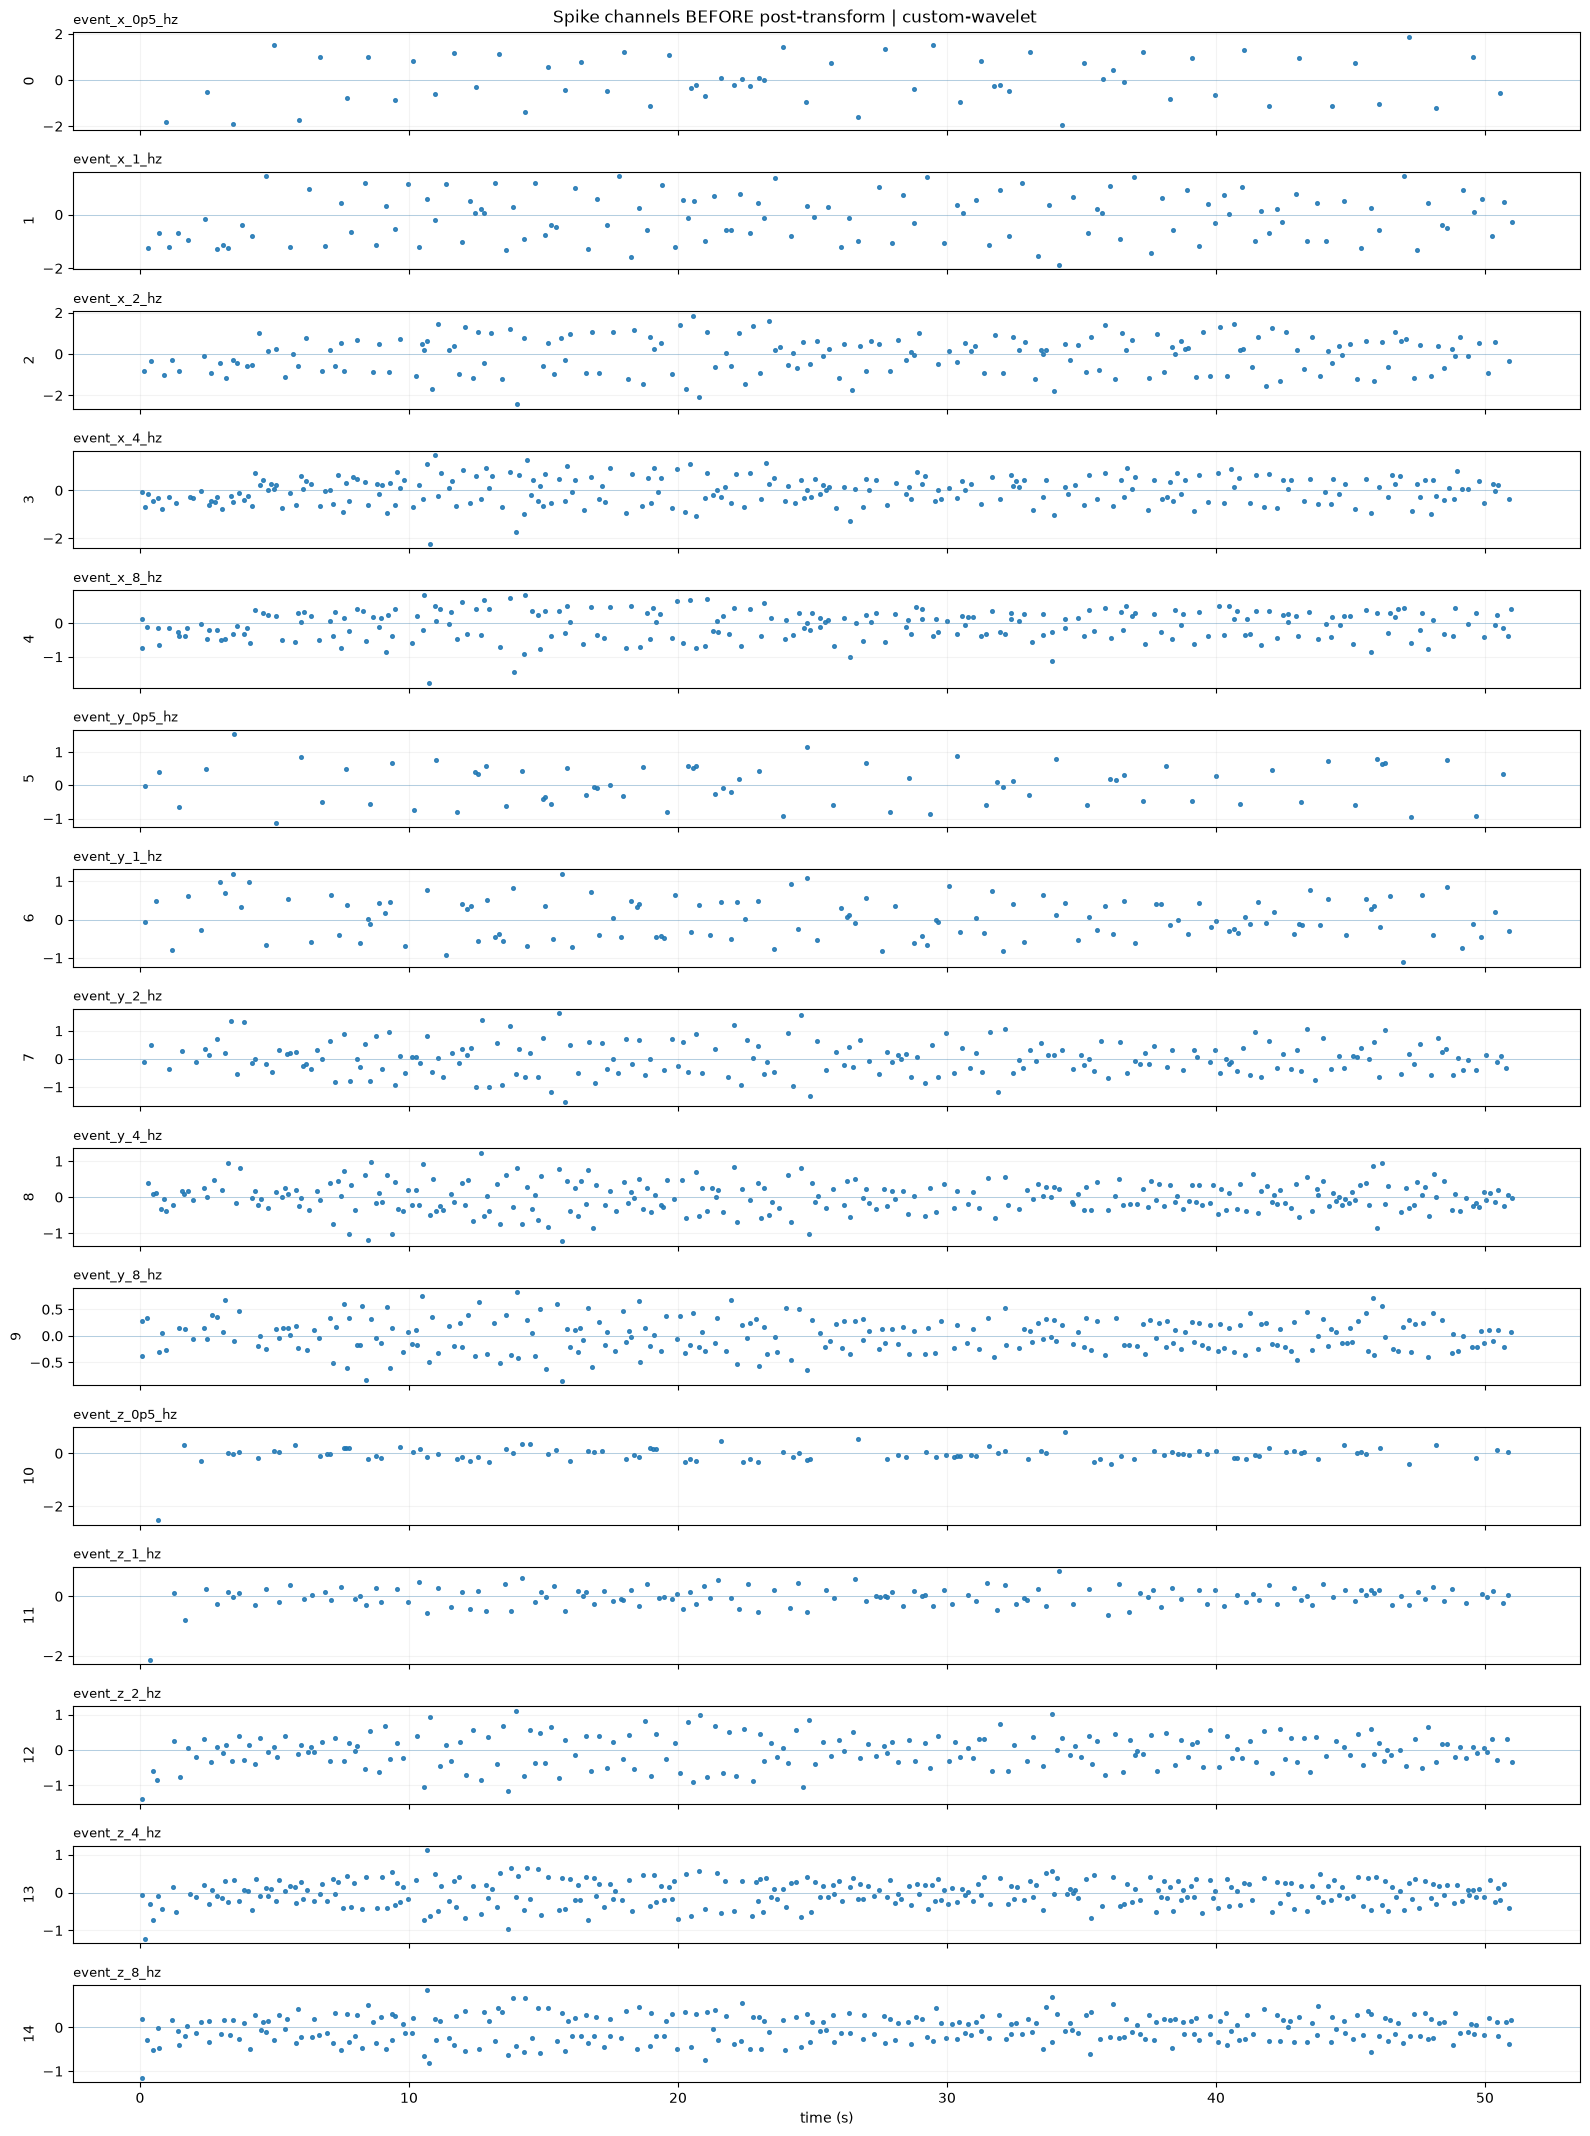

In [10]:
def spike_channel_summary(values: np.ndarray, channel_names: tuple[str, ...]) -> pd.DataFrame:
    values = np.asarray(values)
    if values.ndim != 2 or values.shape[1] != len(channel_names):
        raise ValueError("values/channel_names shape mismatch")
    rows = []
    for channel_index, channel_name in enumerate(channel_names):
        channel = values[:, channel_index]
        nonzero = channel != 0
        rows.append(
            {
                "channel_index": channel_index,
                "channel": channel_name,
                "spike_count": int(np.count_nonzero(nonzero)),
                "positive_count": int(np.count_nonzero(channel > 0)),
                "negative_count": int(np.count_nonzero(channel < 0)),
                "density": float(np.count_nonzero(nonzero) / len(channel)),
                "max_abs_amplitude": float(np.max(np.abs(channel))) if len(channel) else 0.0,
            }
        )
    return pd.DataFrame(rows)


def plot_spike_channels(
    values: np.ndarray,
    channel_names: tuple[str, ...],
    time_axis_s: np.ndarray,
    *,
    title: str,
) -> None:
    values = np.asarray(values)
    if values.shape[0] != len(time_axis_s):
        raise ValueError("Spike rows and time axis must have the same length")

    channel_count = values.shape[1]
    fig, axes = plt.subplots(
        channel_count,
        1,
        figsize=(16, max(10, channel_count * 1.45)),
        sharex=True,
    )
    if channel_count == 1:
        axes = [axes]

    for channel_index, (ax, channel_name) in enumerate(zip(axes, channel_names)):
        channel = values[:, channel_index]
        nonzero = channel != 0
        if np.any(nonzero):
            ax.scatter(time_axis_s[nonzero], channel[nonzero], s=7, alpha=0.85)
        ax.axhline(0.0, linewidth=0.6, alpha=0.35)
        ax.set_ylabel(str(channel_index))
        ax.set_title(channel_name, loc="left", fontsize=9)
        ax.grid(alpha=0.15)

    axes[-1].set_xlabel("time (s)")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


before_post_summary = spike_channel_summary(spikes_before_post, spike_channel_names)
display(before_post_summary)
print(f"Total nonzero events: {before_post_summary['spike_count'].sum():,}")

plot_spike_channels(
    spikes_before_post,
    spike_channel_names,
    time_s,
    title=f"Spike channels BEFORE post-transform | {ENCODER_NAME}",
)


## 6. Post-transform

For `custom-wavelet`, the notebook obtains the post-transform output by creating the same registered encoder with its official `post_encode_transform` setting and re-running the same recording. This deliberately uses the repository implementation rather than duplicating transform logic in notebook code.

For `AbsRectify`, the expected invariant is:

- values after transform equal `abs(values before transform)`;
- nonzero event locations and per-channel spike counts are unchanged;
- negative event counts become zero.


In [11]:
if POST_ENCODE_TRANSFORM not in {None, "AbsRectify"}:
    raise ValueError("Current notebook/repository contract supports POST_ENCODE_TRANSFORM=None or 'AbsRectify'")
if ENCODER_NAME != "custom-wavelet" and POST_ENCODE_TRANSFORM is not None:
    raise ValueError(
        "The current repository exposes post_encode_transform only for custom-wavelet. "
        "Select None or add support in that encoder's implementation first."
    )

post_settings = dict(base_encoder_settings)
if ENCODER_NAME == "custom-wavelet":
    post_settings["post_encode_transform"] = POST_ENCODE_TRANSFORM

encoder_after_post = create_encoder(ENCODER_NAME, settings=post_settings)
encoding_after_post = run_spike_encoder(
    encoder_after_post,
    acceleration_g=preprocessed.acceleration_g,
    sequence_offsets=recording_offsets,
    sequence_boundary_semantics="recording",
)

spikes_after_post = np.asarray(encoding_after_post.values)
after_post_summary = spike_channel_summary(spikes_after_post, encoding_after_post.channel_names)

display(after_post_summary)
print(f"Post-transform: {POST_ENCODE_TRANSFORM}")
print(f"Representation: {encoding_after_post.representation}")
print(f"Total nonzero events: {after_post_summary['spike_count'].sum():,}")

if POST_ENCODE_TRANSFORM == "AbsRectify":
    same_support = np.array_equal(spikes_before_post != 0, spikes_after_post != 0)
    exact_abs_match = np.allclose(spikes_after_post, np.abs(spikes_before_post), rtol=0.0, atol=0.0)
    same_counts = np.array_equal(
        before_post_summary["spike_count"].to_numpy(),
        after_post_summary["spike_count"].to_numpy(),
    )
    print(f"Invariant - same nonzero support: {same_support}")
    print(f"Invariant - output == abs(pre-transform): {exact_abs_match}")
    print(f"Invariant - per-channel spike counts unchanged: {same_counts}")
    if not (same_support and exact_abs_match and same_counts):
        raise AssertionError("AbsRectify invariants failed")


,channel_index,channel,spike_count,positive_count,negative_count,density,max_abs_amplitude
0,0,event_x_0p5_hz,63,63,0,0.006148,1.960027
1,1,event_x_1_hz,125,125,0,0.012199,1.865838
2,2,event_x_2_hz,181,181,0,0.017664,2.429435
3,3,event_x_4_hz,247,247,0,0.024105,2.229251
4,4,event_x_8_hz,234,234,0,0.022836,1.787564
5,5,event_y_0p5_hz,72,72,0,0.007026,1.532376
6,6,event_y_1_hz,130,130,0,0.012687,1.201565
7,7,event_y_2_hz,203,203,0,0.019811,1.628938
8,8,event_y_4_hz,274,274,0,0.026740,1.233652
9,9,event_y_8_hz,256,256,0,0.024983,0.843066


Post-transform: AbsRectify
Representation: abs_rectified_sparse_wavelet_extrema
Total nonzero events: 2,823
Invariant - same nonzero support: True
Invariant - output == abs(pre-transform): True
Invariant - per-channel spike counts unchanged: True


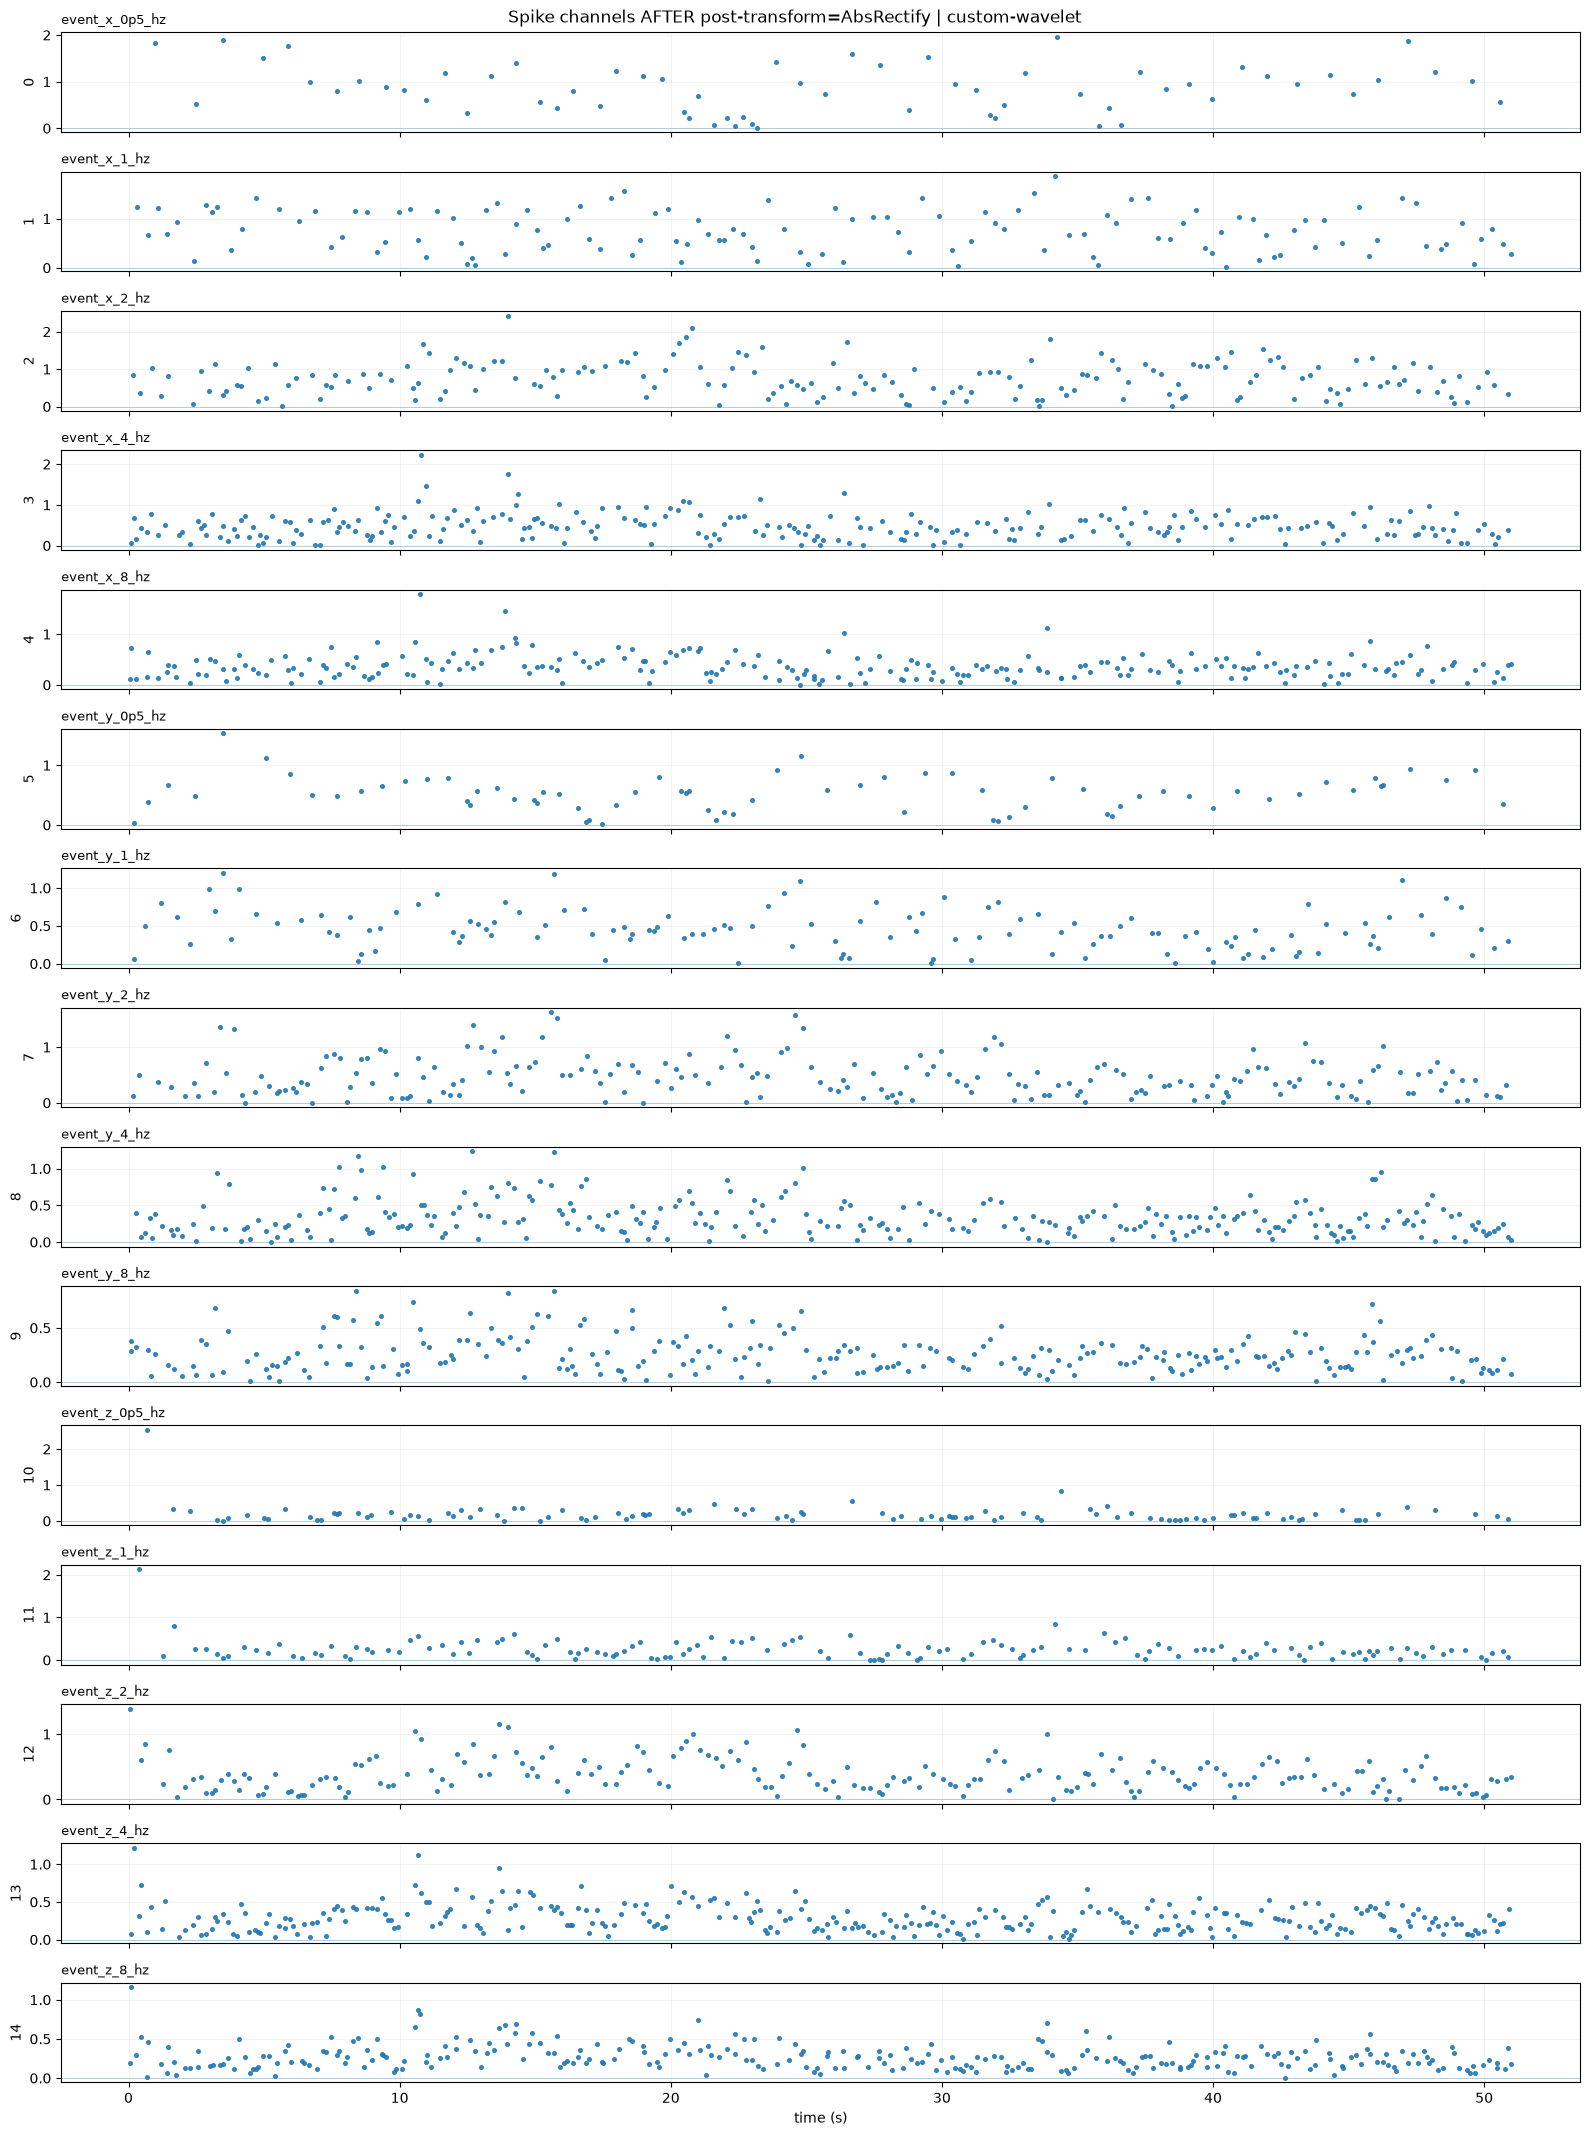

,channel_index,channel,spike_count_before,positive_count_before,negative_count_before,spike_count_after,positive_count_after,negative_count_after
0,0,event_x_0p5_hz,63,30,33,63,63,0
1,1,event_x_1_hz,125,60,65,125,125,0
2,2,event_x_2_hz,181,98,83,181,181,0
3,3,event_x_4_hz,247,129,118,247,247,0
4,4,event_x_8_hz,234,118,116,234,234,0
5,5,event_y_0p5_hz,72,38,34,72,72,0
6,6,event_y_1_hz,130,66,64,130,130,0
7,7,event_y_2_hz,203,100,103,203,203,0
8,8,event_y_4_hz,274,137,137,274,274,0
9,9,event_y_8_hz,256,129,127,256,256,0


In [12]:
plot_spike_channels(
    spikes_after_post,
    encoding_after_post.channel_names,
    time_s,
    title=f"Spike channels AFTER post-transform={POST_ENCODE_TRANSFORM} | {ENCODER_NAME}",
)

comparison = before_post_summary[["channel_index", "channel", "spike_count", "positive_count", "negative_count"]].merge(
    after_post_summary[["channel_index", "spike_count", "positive_count", "negative_count"]],
    on="channel_index",
    suffixes=("_before", "_after"),
)
display(comparison)


## 7. Optional production preprocessing export

This cell uses the repository's canonical `export_discovered_preprocessing()` path. It writes the documented per-recording NPY + canonical timestamps + JSON summary artifact tree.

The switch is off by default and `OVERWRITE=False` by default.


In [13]:
if RUN_BATCH_PREPROCESSING_EXPORT:
    exported = export_discovered_preprocessing(
        data_root=DATA_ROOT,
        output_root=PREPROCESSED_OUTPUT_ROOT,
        gravity_config=preprocessing_config,
        output_dtype=PREPROCESS_OUTPUT_DTYPE,
        overwrite=OVERWRITE,
    )
    export_table = pd.DataFrame(
        [
            {
                "user": result.recording.user,
                "action_id": result.recording.action,
                "dataset_id": result.recording.dataset_id,
                "samples": len(result.imu),
                "imu_path": str(result.output_paths.imu_path),
                "summary_path": str(result.output_paths.summary_path),
            }
            for result in exported
        ]
    )
    display(export_table)
else:
    print("RUN_BATCH_PREPROCESSING_EXPORT=False; no preprocessing artifacts were written.")


RUN_BATCH_PREPROCESSING_EXPORT=False; no preprocessing artifacts were written.


## 8. Optional production spike export

This deliberately invokes the existing `scripts/encode_spikes.py` CLI for batch publication, so metadata validation, canonical timestamp provenance, output layout, atomic publication, and overwrite behavior stay identical to the production script.

The encoder and post-transform are still selected only through the configuration variables at the top of this notebook.


In [14]:
if RUN_BATCH_SPIKE_EXPORT:
    if not PREPROCESSED_OUTPUT_ROOT.is_dir():
        raise RuntimeError(
            f"Preprocessed output root does not exist: {PREPROCESSED_OUTPUT_ROOT}. "
            "Run the preprocessing export first or point PREPROCESSED_OUTPUT_ROOT to existing artifacts."
        )

    command = [
        sys.executable,
        str(REPO_ROOT / "scripts" / "encode_spikes.py"),
        "--input-root", str(PREPROCESSED_OUTPUT_ROOT),
        "--pattern", "*_preprocessedIMU.npy",
        "--output-root", str(SPIKE_OUTPUT_ROOT),
        "--encoder", ENCODER_NAME,
        "--encoder-settings", str(encoder_settings_path),
    ]
    if ENCODER_NAME == "custom-wavelet":
        command += [
            "--post-encode-transform",
            "none" if POST_ENCODE_TRANSFORM is None else POST_ENCODE_TRANSFORM,
        ]
    if OVERWRITE:
        command.append("--overwrite")

    print("Running:")
    print(" ".join(command))
    subprocess.run(command, cwd=REPO_ROOT, check=True)
else:
    print("RUN_BATCH_SPIKE_EXPORT=False; no spike artifacts were written.")


RUN_BATCH_SPIKE_EXPORT=False; no spike artifacts were written.


## 9. Final experiment snapshot

This compact snapshot is useful when saving the notebook alongside figures or experiment notes.


In [15]:
experiment_snapshot = {
    "data_root": str(DATA_ROOT),
    "selected_recording": {
        "user": recording.user,
        "action_id": recording.action,
        "dataset_id": recording.dataset_id,
        "sample_count": len(ring.dataframe),
    },
    "dataset": {
        "user_count": int(inventory["user"].nunique()),
        "action_id_count": int(inventory["action_id"].nunique()),
        "recording_count": int(len(inventory)),
        "raw_sample_count": int(inventory["raw_sample_count"].sum()),
    },
    "preprocessing": {
        "method": GRAVITY_METHOD,
        "sampling_rate_hz": SAMPLING_RATE_HZ,
        "low_pass_cutoff_hz": LOW_PASS_CUTOFF_HZ,
        "madgwick_beta": MADGWICK_BETA,
        "provisional": MADGWICK_PROVISIONAL,
        "output_shape": tuple(preprocessed.imu.shape),
    },
    "spike_encoding": {
        "encoder": ENCODER_NAME,
        "registered_encoders": list(registered_encoders),
        "settings_path": str(encoder_settings_path),
        "pre_transform_representation": encoding_before_post.representation,
        "channel_count": int(spikes_before_post.shape[1]),
        "total_nonzero_events_before_post": int(before_post_summary["spike_count"].sum()),
    },
    "post_transform": {
        "name": POST_ENCODE_TRANSFORM,
        "representation": encoding_after_post.representation,
        "total_nonzero_events_after_post": int(after_post_summary["spike_count"].sum()),
    },
}

print(json.dumps(experiment_snapshot, indent=2))


{
  "data_root": "/home/ted/project/writingring-viz/data",
  "selected_recording": {
    "user": "user_0",
    "action_id": "0",
    "dataset_id": 0,
    "sample_count": 10247
  },
  "dataset": {
    "user_count": 21,
    "action_id_count": 6,
    "recording_count": 606,
    "raw_sample_count": 9642001
  },
  "preprocessing": {
    "method": "low-pass",
    "sampling_rate_hz": 200.0,
    "low_pass_cutoff_hz": 0.2,
    "madgwick_beta": 0.1,
    "provisional": false,
    "output_shape": [
      10247,
      9
    ]
  },
  "spike_encoding": {
    "encoder": "custom-wavelet",
    "registered_encoders": [
      "custom-wavelet"
    ],
    "settings_path": "/home/ted/project/writingring-viz/configs/spike_encoding/custom_wavelet.json",
    "pre_transform_representation": "signed_sparse_wavelet_extrema",
    "channel_count": 15,
    "total_nonzero_events_before_post": 2823
  },
  "post_transform": {
    "name": "AbsRectify",
    "representation": "abs_rectified_sparse_wavelet_extrema",
    "to